# 1.  Importation and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### 1.1 Mounting Directory and Importing the Data

In [2]:
import sys
from pathlib import Path

# Define the Root (at SCANIA COMPONENT X)
PROJECT_ROOT = Path.cwd().parent

# Data Directory (Matches your "Data/Processed Data" folder exactly)
DATA_DIR = PROJECT_ROOT / "Data"


# Adding root to sys.path for imports
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Diagnostic Prints
print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Source:  {DATA_DIR}")


# Test if we can see the data file aka. if the path set-up is correct and the file exists
test_file = DATA_DIR / "train_operational_readouts.csv"
if test_file.exists():
    print(f"Path setup is correct. Found file: {test_file}")
else:
    raise FileNotFoundError(f"Missing expected file: {test_file}")

Project Root: c:\Users\Elias\Documents\SCANIA Component X
Data Source:  c:\Users\Elias\Documents\SCANIA Component X\Data
Path setup is correct. Found file: c:\Users\Elias\Documents\SCANIA Component X\Data\train_operational_readouts.csv


In [3]:
import importlib
import utils

importlib.reload(utils)

<module 'utils' from 'c:\\Users\\Elias\\Documents\\SCANIA Component X\\utils\\__init__.py'>

### 1.2 Loading the Imported Data to Python

In [4]:
# Training data
train_readouts = pd.read_csv(DATA_DIR / 'train_operational_readouts.csv')
train_tte = pd.read_csv(DATA_DIR / 'train_tte.csv')
train_specs = pd.read_csv(DATA_DIR / 'train_specifications.csv')

# Validation data
val_readouts = pd.read_csv(DATA_DIR / 'validation_operational_readouts.csv')
val_labels = pd.read_csv(DATA_DIR / 'validation_labels.csv')
val_specs = pd.read_csv(DATA_DIR / 'validation_specifications.csv')

# Test data
test_readouts = pd.read_csv(DATA_DIR / 'test_operational_readouts.csv')
test_labels = pd.read_csv(DATA_DIR / 'test_labels.csv')
test_specs = pd.read_csv(DATA_DIR / 'test_specifications.csv')

In [5]:
# Check the shape for each dataset
print("=== Dataset Shapes ===")
print(f"Train readouts: {train_readouts.shape}")
print(f"Train TTE:      {train_tte.shape}")
print(f"Train specs:    {train_specs.shape}")
print(f"\nVal readouts:   {val_readouts.shape}")
print(f"Val labels:     {val_labels.shape}")
print(f"Val specs:      {val_specs.shape}")
print(f"\nTest readouts:  {test_readouts.shape}")
print(f"Test labels:    {test_labels.shape}")
print(f"Test specs:     {test_specs.shape}")

# Checking the readouts for the first 5 rows.
print("=== Train Readouts (first 5 rows) ===")
print(train_readouts.head())

print("\n=== Train TTE (first 5 rows) ===")
print(train_tte.head())

print("\n=== Val Labels (first 5 rows) ===")
print(val_labels.head())

=== Dataset Shapes ===
Train readouts: (1122452, 107)
Train TTE:      (23550, 3)
Train specs:    (23550, 9)

Val readouts:   (196227, 107)
Val labels:     (5046, 2)
Val specs:      (5046, 9)

Test readouts:  (198140, 107)
Test labels:    (5045, 2)
Test specs:     (5045, 9)
=== Train Readouts (first 5 rows) ===
   vehicle_id  time_step     171_0    666_0       427_0   837_0   167_0  \
0           0       11.2  167985.0  10787.0   7413813.0  2296.0  4110.0   
1           0       11.4  167985.0  10787.0   7413813.0  2296.0  4111.0   
2           0       19.6  331635.0  14525.0  13683604.0  2600.0     NaN   
3           0       20.2  354975.0  15015.0  14540449.0  2616.0     NaN   
4           0       21.0  365550.0  15295.0  14966985.0  2720.0     NaN   

       167_1      167_2     167_3  ...    397_26   397_27  397_28  397_29  \
0  1296420.0  1628265.0  630345.0  ...   95728.0  15609.0  1984.0     8.0   
1  1302855.0  1628265.0  630345.0  ...   95729.0  15610.0  1984.0     8.0   
2     

# 2. Exploratory Data Analysis

### 2.1 Class Distribution

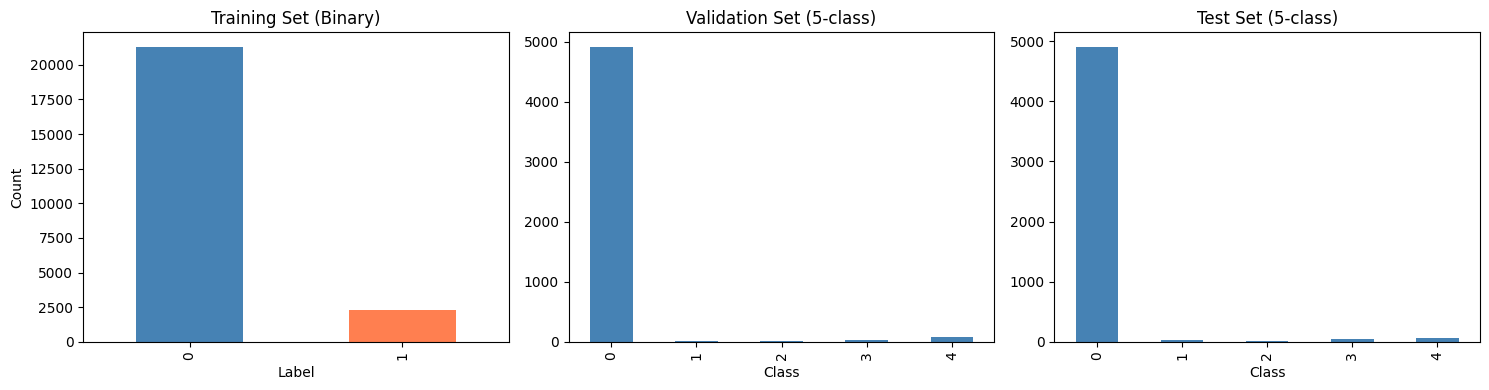

=== Missing Values (%) ===
291_10    0.857765
291_9     0.857765
291_8     0.857765
291_2     0.857765
291_4     0.857765
            ...   
272_3     0.046773
666_0     0.003564
837_0     0.003475
835_0     0.003475
309_0     0.003029
Length: 104, dtype: float64

Max missing: 0.86%


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Training: binary
train_tte['in_study_repair'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Training Set (Binary)')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')

# Validation: 5-class
val_labels['class_label'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Validation Set (5-class)')
axes[1].set_xlabel('Class')

# Test: 5-class
test_labels['class_label'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('Test Set (5-class)')
axes[2].set_xlabel('Class')

plt.tight_layout()
plt.show()

# Missing value percentage per column
missing_pct = train_readouts.isnull().mean() * 100
print("=== Missing Values (%) ===")
print(missing_pct[missing_pct > 0].sort_values(ascending=False))
print(f"\nMax missing: {missing_pct.max():.2f}%")

### 2.2 Readouts per Vehicles

=== Readouts per Vehicle ===
count    23550.000000
mean        47.662505
std         27.406028
min          5.000000
25%         28.000000
50%         43.000000
75%         64.000000
max        303.000000
dtype: float64


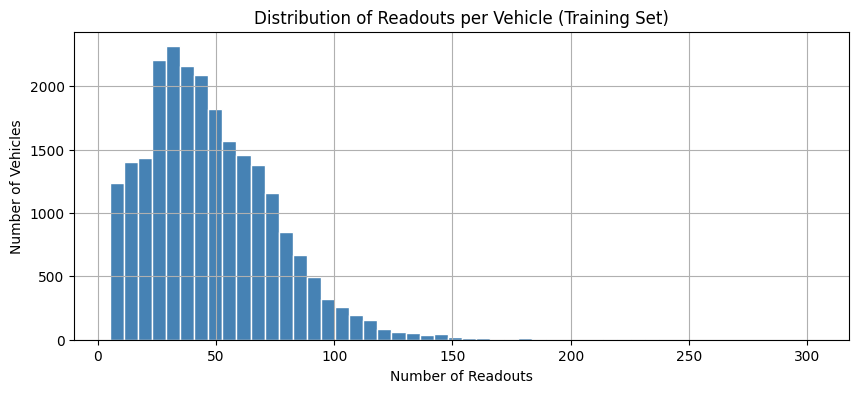

In [7]:
readouts_per_vehicle = train_readouts.groupby('vehicle_id').size()

print("=== Readouts per Vehicle ===")
print(readouts_per_vehicle.describe())

fig, ax = plt.subplots(figsize=(10, 4))
readouts_per_vehicle.hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Distribution of Readouts per Vehicle (Training Set)')
ax.set_xlabel('Number of Readouts')
ax.set_ylabel('Number of Vehicles')
plt.show()

### 2.3 Distribution of Readouts Per Vehicle  

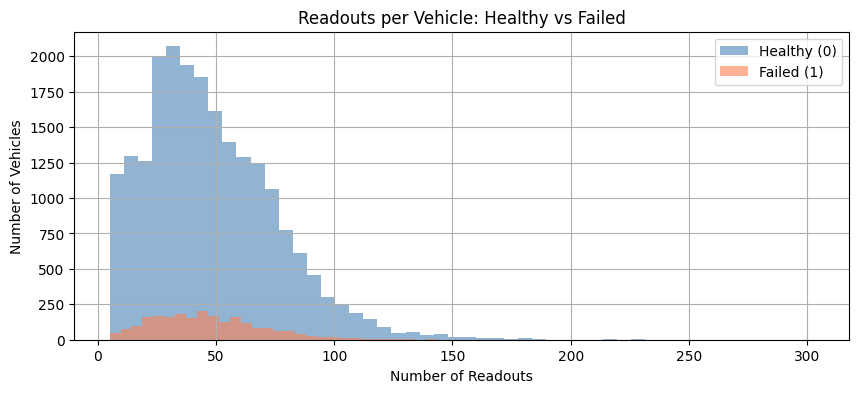

In [8]:
merged = train_readouts.groupby('vehicle_id').size().reset_index(name='num_readouts')
merged = merged.merge(train_tte[['vehicle_id', 'in_study_repair']], on='vehicle_id')

fig, ax = plt.subplots(figsize=(10, 4))
merged[merged['in_study_repair'] == 0]['num_readouts'].hist(bins=50, ax=ax, alpha=0.6, label='Healthy (0)', color='steelblue')
merged[merged['in_study_repair'] == 1]['num_readouts'].hist(bins=50, ax=ax, alpha=0.6, label='Failed (1)', color='coral')
ax.set_title('Readouts per Vehicle: Healthy vs Failed')
ax.set_xlabel('Number of Readouts')
ax.set_ylabel('Number of Vehicles')
ax.legend()
plt.show()

### 2.4 Comparison of Single Feature Evolution Over Time - Healthy vs Failed

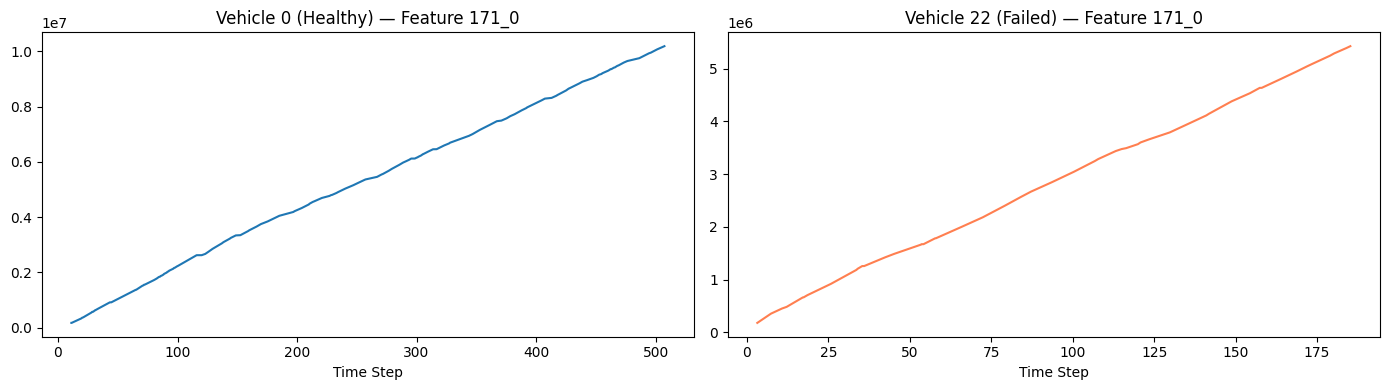

In [9]:
# 2. How does a single feature evolve over time for a healthy vs failed vehicle?
healthy_id = train_tte[train_tte['in_study_repair'] == 0]['vehicle_id'].iloc[0]
failed_id = train_tte[train_tte['in_study_repair'] == 1]['vehicle_id'].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

healthy_data = train_readouts[train_readouts['vehicle_id'] == healthy_id]
failed_data = train_readouts[train_readouts['vehicle_id'] == failed_id]

axes[0].plot(healthy_data['time_step'], healthy_data['171_0'])
axes[0].set_title(f'Vehicle {healthy_id} (Healthy) — Feature 171_0')
axes[0].set_xlabel('Time Step')

axes[1].plot(failed_data['time_step'], failed_data['171_0'], color='coral')
axes[1].set_title(f'Vehicle {failed_id} (Failed) — Feature 171_0')
axes[1].set_xlabel('Time Step')

plt.tight_layout()
plt.show()

### 2.5 Conclusions

The EDA reveals a dataset that is relativley clean, but structurally challenging. As has been noted in the paper on this dataset, it is evidently severly imbalanced. Failures are rare event and make up around 10% of the training data and under 3% of the validation and test data.

Moerover, we observe that the healthy and failed vehicles follow similar readout length distributions, which means we cannot rely on sequence length as a shortcut for prediction. Instead, we must use the actual sensor patterns within the sequence to train the model.

Practically, the data requieres true key transformations before modelling. Sequences need to be standardized for the temporal models and the cumultive features need to be vonverted to delras to capute meaningful change patterns not absolute values. Missing data is negliable, however will be imputed with a simple imputator.


In [10]:
train_tte.head()

,vehicle_id,length_of_study_time_step,in_study_repair
0,0,510.0,0
1,2,281.8,0
2,3,293.4,0
3,4,210.0,0
4,5,360.4,0


# 3. Preprocessing

## 3.1 Feature Engineering


Val and test labels use a 5-class systemm where 0 = healthy, 1-4 = Different failures with different costs. We use binirize and use a class > 0 = failure, collapsing all failure classes into one positive label.

In [11]:
train_data = train_readouts.merge(train_tte[['vehicle_id', 'in_study_repair']], on='vehicle_id')

#Adding a binary label to validation and test sets
val_labels['binary_label'] = (val_labels['class_label'] > 0).astype(int)
test_labels['binary_label'] = (test_labels['class_label'] > 0).astype(int)

# Merging the data with binary as well as ID
val_data = val_readouts.merge(val_labels[['vehicle_id', 'binary_label']], on='vehicle_id')
test_data = test_readouts.merge(test_labels[['vehicle_id', 'binary_label']], on='vehicle_id')


In [12]:
# Verifications:
print(f"train_data shape: {train_data.shape}")
print(f"val_data shape:   {val_data.shape}")
print(f"test_data shape:  {test_data.shape}")

print(f"\nTrain label column: 'in_study_repair'")
print(train_data['in_study_repair'].value_counts())

print(f"\nVal binary label:")
print(val_data.groupby('vehicle_id')['binary_label'].first().value_counts())

print(f"\nTest binary label:")
print(test_data.groupby('vehicle_id')['binary_label'].first().value_counts())

train_data shape: (1122452, 108)
val_data shape:   (196227, 108)
test_data shape:  (198140, 108)

Train label column: 'in_study_repair'
in_study_repair
0    1016600
1     105852
Name: count, dtype: int64

Val binary label:
binary_label
0    4910
1     136
Name: count, dtype: int64

Test binary label:
binary_label
0    4903
1     142
Name: count, dtype: int64


### 3.2 Handle Missing Values With Forward-Fill
From section 2 we can conclude that less than 1% of the values are missing. However, our chosen models cannot handle NaN values which is why it still needs to be adressed. We use a Forward-Fill since we assume that if a value is missing, it is because it has not been changed. Morover, we will also assume that if a value cannot be forwared filled it is because it did not have a value before-hand, essentially making it reasonable to set it to 0.

### 3.3 Computing Deltas and Normalizing
We saw from the EDA that numerical counters accumulate over time. However, the raw value of those features does not tell us anything straight away. In order to get a better understanding we can subtract those values from the previous, as to see the delta, or change, which tells us how much has happend in this specific interval instead.

#### 3.3.1 Meging Specifications and Initial Labeling

In [13]:
train_data = train_readouts.merge(train_tte[['vehicle_id', 'in_study_repair']], on='vehicle_id')

val_labels['binary_label'] = (val_labels['class_label'] > 0).astype(int)
val_data = val_readouts.merge(val_labels[['vehicle_id', 'binary_label']], on='vehicle_id')

test_labels['binary_label'] = (test_labels['class_label'] > 0).astype(int)
test_data = test_readouts.merge(test_labels[['vehicle_id', 'binary_label']], on='vehicle_id')

def apply_warning_window(df, label_col, window_size=30):
    df = df.copy()
    df['target'] = 0
    failed_vehicles = df[df[label_col] == 1]['vehicle_id'].unique()
    for vid in failed_vehicles:
        idx = df[df['vehicle_id'] == vid].tail(window_size).index
        df.loc[idx, 'target'] = 1
    return df

train_data = apply_warning_window(train_data, 'in_study_repair')
val_data = apply_warning_window(val_data, 'binary_label')
test_data = apply_warning_window(test_data, 'binary_label')

train_data = train_data.drop(columns=['in_study_repair']).rename(columns={'target': 'label'}).copy()
val_data = val_data.drop(columns=['binary_label']).rename(columns={'target': 'label'}).copy()
test_data = test_data.drop(columns=['binary_label']).rename(columns={'target': 'label'}).copy()

#### 3.3.2 - Imputation  

In [14]:
# Sort by vehicle and time
train_data = train_data.sort_values(['vehicle_id', 'time_step'])
val_data = val_data.sort_values(['vehicle_id', 'time_step'])
test_data = test_data.sort_values(['vehicle_id', 'time_step'])

# Identify non-numeric columns to exclude from imputation
non_numeric_cols = [c for c in train_data.columns if not pd.api.types.is_numeric_dtype(train_data[c])]

# Identify feature columns, excluding IDs, labels and non-numeric
train_feature_cols = [c for c in train_data.columns if c not in ['vehicle_id', 'time_step', 'label'] + non_numeric_cols]
valtest_feature_cols = [c for c in val_data.columns if c not in ['vehicle_id', 'time_step', 'label'] + non_numeric_cols]

# Forward fill only — no bfill to avoid leaking future values into the past
train_data[train_feature_cols] = train_data.groupby('vehicle_id')[train_feature_cols].ffill()
val_data[valtest_feature_cols] = val_data.groupby('vehicle_id')[valtest_feature_cols].ffill()
test_data[valtest_feature_cols] = test_data.groupby('vehicle_id')[valtest_feature_cols].ffill()

# Fill remaining NaNs using train median to prevent leakage
for col in train_feature_cols:
    fill_val = train_data[col].median()
    train_data[col] = train_data[col].fillna(fill_val)
    val_data[col] = val_data[col].fillna(fill_val)
    test_data[col] = test_data[col].fillna(fill_val)

# Defragment to avoid PerformanceWarning
train_data = train_data.copy()
val_data = val_data.copy()
test_data = test_data.copy()

# Verify
print(f"Train missing: {train_data.isnull().sum().sum()}")
print(f"Val missing:   {val_data.isnull().sum().sum()}")
print(f"Test missing:  {test_data.isnull().sum().sum()}")

Train missing: 0
Val missing:   0
Test missing:  0


#### 3.3.3 - Selective Differencing and Normalizaion

In [15]:
from sklearn.preprocessing import RobustScaler

# 1. Drop spec columns entirely
spec_cols = [c for c in train_data.columns if not pd.api.types.is_numeric_dtype(train_data[c])]
train_data = train_data.drop(columns=spec_cols)
val_data = val_data.drop(columns=spec_cols)
test_data = test_data.drop(columns=spec_cols)

# 2. Define columns
exclude = ['vehicle_id', 'time_step', 'label']
numeric_features = [c for c in train_data.columns if c not in exclude]

# 3. Identify cumulative columns and replace with deltas
cum_cols = utils.get_cumulative_cols(train_data, numeric_features)

train_deltas = pd.concat([
    train_data.groupby('vehicle_id')[col].diff().fillna(0).rename(f'{col}_delta')
    for col in cum_cols
], axis=1)
val_deltas = pd.concat([
    val_data.groupby('vehicle_id')[col].diff().fillna(0).rename(f'{col}_delta')
    for col in cum_cols
], axis=1)
test_deltas = pd.concat([
    test_data.groupby('vehicle_id')[col].diff().fillna(0).rename(f'{col}_delta')
    for col in cum_cols
], axis=1)

train_data = pd.concat([train_data, train_deltas], axis=1).drop(columns=cum_cols).copy()
val_data = pd.concat([val_data, val_deltas], axis=1).drop(columns=cum_cols).copy()
test_data = pd.concat([test_data, test_deltas], axis=1).drop(columns=cum_cols).copy()

# 4. Update feature list
all_features = [c for c in train_data.columns if c not in exclude]
assert list(train_data[all_features].columns) == list(val_data[all_features].columns), "Feature mismatch between train and val"

# 5. Clip outliers using train quantiles
for col in all_features:
    lower = train_data[col].quantile(0.005)
    upper = train_data[col].quantile(0.995)
    train_data[col] = train_data[col].clip(lower, upper)
    val_data[col] = val_data[col].clip(lower, upper)
    test_data[col] = test_data[col].clip(lower, upper)

# 6. Scale
scaler = RobustScaler()
train_data[all_features] = scaler.fit_transform(train_data[all_features])
val_data[all_features] = scaler.transform(val_data[all_features])
test_data[all_features] = scaler.transform(test_data[all_features])

# 7. Defragment
train_data = train_data.copy()
val_data = val_data.copy()
test_data = test_data.copy()

print(f"Dropped spec columns: {spec_cols}")
print(f"Cumulative cols diffed: {len(cum_cols)}")
print(f"Final feature count: {len(all_features)}")
print(f"Train missing: {train_data.isnull().sum().sum()}")
print(f"Val missing:   {val_data.isnull().sum().sum()}")
print(f"Test missing:  {test_data.isnull().sum().sum()}")

Dropped spec columns: []
Cumulative cols diffed: 105
Final feature count: 105
Train missing: 0
Val missing:   0
Test missing:  0


# 4. Saving and Exporting the Data

In [16]:
import joblib

SAVE_DIR = DATA_DIR / 'Processed Data/'
print('Saving....')
train_data.to_csv(SAVE_DIR / 'train_processed.csv', index=False)
print('Train saved.')

val_data.to_csv(SAVE_DIR / 'val_processed.csv', index=False)
print('Validation saved.')

test_data.to_csv(SAVE_DIR / 'test_processed.csv', index=False)
print('Test saved.')

val_labels.to_csv(SAVE_DIR / 'val_labels_original.csv', index=False)
print('Validation labels saved.')

test_labels.to_csv(SAVE_DIR / 'test_labels_original.csv', index=False)
print('Test labels saved.')

joblib.dump(scaler, SAVE_DIR / 'scaler.joblib')
print("Scaler saved.")

print('Done!')

Saving....
Train saved.
Validation saved.
Test saved.
Validation labels saved.
Test labels saved.
Scaler saved.
Done!
